In [1]:
# ============================================================
# CELL 1 — UPDATED ENV: UAVPriorityRealloc3DEnv
# Adds TANet-style episode metrics:
#   - ep_dist per UAV
#   - coll_uav_uav, coll_uav_obs, coll_uav_other_task
#   - finish_step_per_uav
# Exposes them in info every step
# ============================================================

import numpy as np
import gym
from gym import spaces
from scipy.optimize import linear_sum_assignment


class UAVPriorityRealloc3DEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        seed=0,
        max_steps=100,
        priority_change_every=250,
        n_uavs=4,
        n_tasks=4,
        n_high=4,
        progress_gain=2.0,
        n_obstacles=2,
        time_penalty=0.01,
        # metric collision radius (matches your other env style)
        ru=0.02,
    ):
        super().__init__()

        # RNG
        self._np_rng = np.random.default_rng(seed)

        # ==============================
        # CONFIGURATION
        # ==============================
        self.n_uavs = int(n_uavs)
        self.n_tasks = int(n_tasks)
        self.n_high = int(n_high)
        self.n_obstacles = int(n_obstacles)
        self.max_steps = int(max_steps)
        self.priority_change_every = int(priority_change_every)
        self.progress_gain = float(progress_gain)
        self.time_penalty = float(time_penalty)
        self.ru = float(ru)

        # ==============================
        # WORLD BOUNDS
        # ==============================
        self.min_pos, self.max_pos = -1.0, 1.0
        self.min_z, self.max_z = 0.0, 1.0
        self.max_velocity = 0.05

        # ==============================
        # GEOMETRY (CENTER-BASED BLOCKS)
        # ==============================
        self.obs_half_xy = np.array([0.20, 0.20], dtype=np.float32)
        self.target_half_xy = np.array([0.08, 0.08], dtype=np.float32)

        self.obs_height_range = (0.4, 0.9)
        self.target_height_range = (0.3, 0.7)

        self.clearance = (
            np.linalg.norm(self.obs_half_xy)
            + np.linalg.norm(self.target_half_xy)
            + 0.05
        )

        # ==============================
        # OBSERVATION SPACE
        # ==============================
        # uav(3) + rel_target(3) + rel_nearest_obs(3) + rel_other_uavs(3*(n_uavs-1))
        obs_dim = 3 + 3 + 3 + (self.n_uavs - 1) * 3

        self.action_space = spaces.Box(
            low=-self.max_velocity,
            high=self.max_velocity,
            shape=(3,),
            dtype=np.float32,
        )

        self.observation_space = spaces.Box(
            low=-2.0,
            high=2.0,
            shape=(obs_dim,),
            dtype=np.float32,
        )

        # ==============================
        # STATE
        # ==============================
        self.uav_pos = None               # (n_uavs, 3)
        self.obs_pos = None               # (n_obstacles, 3) centers
        self.task_pos = None              # (n_tasks, 3) centers

        self.obs_half_z = None            # (n_obstacles,) half-height per obstacle
        self.target_half_z = None         # (n_tasks,) half-height per target

        self.task_priority = None         # (n_tasks,) int 1=HIGH, 0=LOW
        self.assigned = None              # dict {uav_i: task_j}

        self.locked = None                # list[bool] length n_uavs
        self.on_target = None             # list[bool] length n_uavs (completion latched)
        self.task_claimed = None          # list[bool] length n_tasks (window-based)

        self.prev_d = None                # (n_uavs,) float distance tracker

        # Window-based completion tracking (resets each priority change)
        self.task_done = np.zeros(self.n_tasks, dtype=bool)
        self.task_done_by = -np.ones(self.n_tasks, dtype=int)
        self.task_done_step = -np.ones(self.n_tasks, dtype=int)

        self.step_count = 0

        # ==============================
        # EPISODE METRICS (for comparison)
        # ==============================
        self.ep_dist = None                 # (n_uavs,)
        self.coll_uav_uav = 0
        self.coll_uav_obs = 0
        self.coll_uav_other_task = 0
        self.finish_step_per_uav = None     # (n_uavs,)

    # --------------------------------------------------
    # GEOMETRY CHECK (axis-aligned block)
    # --------------------------------------------------
    def _inside_block(self, p, c, half_xy, half_z):
        return (
            abs(float(p[0]) - float(c[0])) <= float(half_xy[0])
            and abs(float(p[1]) - float(c[1])) <= float(half_xy[1])
            and abs(float(p[2]) - float(c[2])) <= float(half_z)
        )

    # --------------------------------------------------
    # SAMPLING (NO OVERLAP, GROUNDED CENTERS)
    # --------------------------------------------------
    def _sample_positions(self):
        # UAVs
        self.uav_pos = self._np_rng.uniform(
            [self.min_pos, self.min_pos, self.min_z],
            [self.max_pos, self.max_pos, self.max_z],
            size=(self.n_uavs, 3),
        ).astype(np.float32)

        # -------- Obstacles --------
        obs_list, obs_half_z = [], []

        while len(obs_list) < self.n_obstacles:
            xy = self._np_rng.uniform(
                [self.min_pos, self.min_pos],
                [self.max_pos, self.max_pos],
                size=(2,),
            ).astype(np.float32)

            if all(
                np.linalg.norm(xy - np.array(o[:2], dtype=np.float32))
                >= 2.0 * np.linalg.norm(self.obs_half_xy)
                for o in obs_list
            ):
                h = float(self._np_rng.uniform(*self.obs_height_range))
                obs_list.append([float(xy[0]), float(xy[1]), h / 2.0])
                obs_half_z.append(h / 2.0)

        self.obs_pos = np.array(obs_list, dtype=np.float32)
        self.obs_half_z = np.array(obs_half_z, dtype=np.float32)

        # -------- Targets (buildings) --------
        task_list, target_half_z = [], []

        while len(task_list) < self.n_tasks:
            xy = self._np_rng.uniform(
                [self.min_pos, self.min_pos],
                [self.max_pos, self.max_pos],
                size=(2,),
            ).astype(np.float32)

            ok = True

            # keep targets away from obstacles
            for o in self.obs_pos:
                if np.linalg.norm(xy - o[:2]) < self.clearance:
                    ok = False
                    break

            # keep targets separated from each other
            if ok:
                for t in task_list:
                    if np.linalg.norm(
                        xy - np.array(t[:2], dtype=np.float32)
                    ) < 2.0 * np.linalg.norm(self.target_half_xy):
                        ok = False
                        break

            if ok:
                h = float(self._np_rng.uniform(*self.target_height_range))
                task_list.append([float(xy[0]), float(xy[1]), h / 2.0])
                target_half_z.append(h / 2.0)

        self.task_pos = np.array(task_list, dtype=np.float32)
        self.target_half_z = np.array(target_half_z, dtype=np.float32)

    # --------------------------------------------------
    # PRIORITY
    # --------------------------------------------------
    def _choose_new_high_priority_set(self):
        high = self._np_rng.choice(self.n_tasks, self.n_high, replace=False)
        self.task_priority = np.zeros(self.n_tasks, dtype=int)
        self.task_priority[high] = 1

    def get_high_priority_tasks(self):
        return np.where(self.task_priority == 1)[0].tolist()

    # --------------------------------------------------
    # OBSERVATION
    # --------------------------------------------------
    def build_obs_for_uav_task(self, i, j):
        uav = self.uav_pos[i]
        tgt = self.task_pos[j]

        idx = int(np.argmin([np.linalg.norm(uav[:2] - o[:2]) for o in self.obs_pos]))
        nearest_obs = self.obs_pos[idx]

        others = []
        for k in range(self.n_uavs):
            if k != i:
                others.extend((self.uav_pos[k] - uav).tolist())

        return np.concatenate(
            [uav, tgt - uav, nearest_obs - uav, np.array(others, dtype=np.float32)]
        ).astype(np.float32)

    def _get_obs(self):
        return [self.build_obs_for_uav_task(i, int(self.assigned[i])) for i in range(self.n_uavs)]

    # --------------------------------------------------
    # ASSIGNMENT (USED BY RL or external scheduler)
    # --------------------------------------------------
    def set_assignment(self, mapping: dict):
        if self.assigned is None:
            self.assigned = dict(mapping)
            self.prev_d = np.zeros(self.n_uavs, dtype=np.float32)
            self.on_target = [False] * self.n_uavs
            for i in range(self.n_uavs):
                j = int(self.assigned[i])
                self.prev_d[i] = float(np.linalg.norm(self.uav_pos[i] - self.task_pos[j]))
            return

        new_map = dict(self.assigned)

        for i in range(self.n_uavs):
            cur = int(self.assigned[i])
            des = int(mapping[i])

            # locked UAVs cannot change task
            if self.locked[i]:
                des = cur

            # cannot switch into claimed task (within this window)
            if des != cur and self.task_claimed[des]:
                des = cur

            new_map[i] = des

            # reset progress + completion latch if assignment changed
            if des != cur:
                self.on_target[i] = False
                self.prev_d[i] = float(np.linalg.norm(self.uav_pos[i] - self.task_pos[des]))

        self.assigned = new_map

    # --------------------------------------------------
    # RESET
    # --------------------------------------------------
    def reset(self, seed=None, options=None):
        if seed is not None:
            self._np_rng = np.random.default_rng(seed)

        self.step_count = 0
        self._sample_positions()
        self._choose_new_high_priority_set()

        self.locked = [False] * self.n_uavs
        self.on_target = [False] * self.n_uavs
        self.task_claimed = [False] * self.n_tasks
        self.prev_d = np.zeros(self.n_uavs, dtype=np.float32)

        # Window-based completion tracking
        self.task_done[:] = False
        self.task_done_by[:] = -1
        self.task_done_step[:] = -1

        # ---- metrics reset ----
        self.ep_dist = np.zeros(self.n_uavs, dtype=np.float32)
        self.coll_uav_uav = 0
        self.coll_uav_obs = 0
        self.coll_uav_other_task = 0
        self.finish_step_per_uav = -np.ones(self.n_uavs, dtype=int)

        # initial Hungarian on HIGH tasks
        high = self.get_high_priority_tasks()
        dist = np.zeros((self.n_uavs, len(high)), dtype=np.float32)

        for i in range(self.n_uavs):
            for c, j in enumerate(high):
                dist[i, c] = float(np.linalg.norm(self.uav_pos[i] - self.task_pos[j]))

        rows, cols = linear_sum_assignment(dist)
        self.assigned = {int(r): int(high[c]) for r, c in zip(rows, cols)}

        for i in range(self.n_uavs):
            j = int(self.assigned[i])
            self.prev_d[i] = float(np.linalg.norm(self.uav_pos[i] - self.task_pos[j]))

        info = {
            "priority_changed": False,
            "task_priority": self.task_priority.copy(),
            "high_tasks": self.get_high_priority_tasks(),
            "high_priority": self.get_high_priority_tasks(),
            "assigned": dict(self.assigned),
            "completion_events": [],
            "task_done": self.task_done.copy(),
            "tasks_done_ids": [],
            # metrics (at reset)
            "ep_dist": self.ep_dist.copy(),
            "coll_uav_uav": int(self.coll_uav_uav),
            "coll_uav_obs": int(self.coll_uav_obs),
            "coll_uav_other_task": int(self.coll_uav_other_task),
            "finish_step_per_uav": self.finish_step_per_uav.copy(),
            "step": int(self.step_count),
        }
        return self._get_obs(), info

    # --------------------------------------------------
    # STEP
    # --------------------------------------------------
    def step(self, actions):
        self.step_count += 1
        info = {}

        # ---------- PRIORITY CHANGE ----------
        priority_changed = (self.step_count % self.priority_change_every == 0)
        if priority_changed:
            self._choose_new_high_priority_set()

            # unlock all and clear claims (and completion latch)
            self.locked = [False] * self.n_uavs
            self.on_target = [False] * self.n_uavs
            self.task_claimed = [False] * self.n_tasks

            # Option A: reset completion state per window
            self.task_done[:] = False
            self.task_done_by[:] = -1
            self.task_done_step[:] = -1

            # reassign to current HIGH tasks via Hungarian
            high = self.get_high_priority_tasks()
            dist = np.zeros((self.n_uavs, len(high)), dtype=np.float32)
            for i in range(self.n_uavs):
                for c, j in enumerate(high):
                    dist[i, c] = float(np.linalg.norm(self.uav_pos[i] - self.task_pos[j]))

            rows, cols = linear_sum_assignment(dist)
            self.assigned = {int(r): int(high[c]) for r, c in zip(rows, cols)}

            # reset distance tracking for progress reward
            for i in range(self.n_uavs):
                j = int(self.assigned[i])
                self.prev_d[i] = float(np.linalg.norm(self.uav_pos[i] - self.task_pos[j]))

            info["priority_changed"] = True
        else:
            info["priority_changed"] = False

        # ---------- UAV MOTION + DISTANCE METRIC ----------
        prev_pos = self.uav_pos.copy()

        for i in range(self.n_uavs):
            if self.locked[i]:
                continue
            a = np.clip(np.array(actions[i], dtype=np.float32), -self.max_velocity, self.max_velocity)
            self.uav_pos[i] += a
            self.uav_pos[i][:2] = np.clip(self.uav_pos[i][:2], self.min_pos, self.max_pos)
            self.uav_pos[i][2] = np.clip(self.uav_pos[i][2], self.min_z, self.max_z)

        step_disp = np.linalg.norm(self.uav_pos - prev_pos, axis=1).astype(np.float32)
        self.ep_dist += step_disp

        # ---------- UAV-UAV collisions (sphere approx) ----------
        for i in range(self.n_uavs):
            for k in range(i + 1, self.n_uavs):
                if float(np.linalg.norm(self.uav_pos[i] - self.uav_pos[k])) <= (2.0 * self.ru):
                    self.coll_uav_uav += 1

        rewards = np.zeros(self.n_uavs, dtype=np.float32)
        dones = np.zeros(self.n_uavs, dtype=bool)
        completion_events = []

        # ---------- REWARDS + COMPLETION ----------
        for i in range(self.n_uavs):

            # locked UAVs are not penalized/rewarded anymore in this window
            if self.locked[i]:
                continue

            j = int(self.assigned[i])
            d = float(np.linalg.norm(self.uav_pos[i] - self.task_pos[j]))
            pr = int(self.task_priority[j])  # 1=HIGH, 0=LOW

            # distance penalty (stronger if HIGH)
            rewards[i] += -(0.6 if pr else 0.1) * d

            # progress shaping (only for unlocked UAVs)
            rewards[i] += float(self.progress_gain) * float(self.prev_d[i] - d)
            self.prev_d[i] = d

            # obstacle penalty (box collision) + metric
            for k, o in enumerate(self.obs_pos):
                if self._inside_block(self.uav_pos[i], o, self.obs_half_xy, self.obs_half_z[k]):
                    rewards[i] -= 5.0
                    self.coll_uav_obs += 1

            # other targets as obstacles + metric
            for j2 in range(self.n_tasks):
                if j2 == j:
                    continue
                if self._inside_block(self.uav_pos[i], self.task_pos[j2], self.target_half_xy, self.target_half_z[j2]):
                    rewards[i] -= 5.0
                    self.coll_uav_other_task += 1

            # completion (within window): only once, exclusivity enforced
            inside = self._inside_block(
                self.uav_pos[i],
                self.task_pos[j],
                self.target_half_xy,
                self.target_half_z[j],
            )

            if inside and (not self.on_target[i]) and (not self.task_claimed[j]):
                rewards[i] += 15.0 if pr else 2.0
                self.on_target[i] = True
                self.locked[i] = True
                self.task_claimed[j] = True

                self.task_done[j] = True
                self.task_done_by[j] = i
                self.task_done_step[j] = self.step_count

                # metric: finish step per UAV (first time it locks)
                self.finish_step_per_uav[i] = int(self.step_count)

                completion_events.append(
                    {"step": self.step_count, "uav": i, "task": j, "priority": pr}
                )

            # time penalty only for unlocked UAVs
            rewards[i] -= float(self.time_penalty)

        # ---------- TERMINATION ----------
        if self.step_count >= self.max_steps:
            dones[:] = True
            
        if all(self.locked):
            dones[:] = True

        # ---------- INFO ----------
        info["task_priority"] = self.task_priority.copy()
        info["high_tasks"] = self.get_high_priority_tasks()
        info["high_priority"] = info["high_tasks"]
        info["assigned"] = dict(self.assigned)
        info["completion_events"] = completion_events
        info["task_done"] = self.task_done.copy()
        info["tasks_done_ids"] = np.where(self.task_done)[0].tolist()

        # metrics like your TANet env
        info["ep_dist"] = self.ep_dist.copy()
        info["coll_uav_uav"] = int(self.coll_uav_uav)
        info["coll_uav_obs"] = int(self.coll_uav_obs)
        info["coll_uav_other_task"] = int(self.coll_uav_other_task)
        info["finish_step_per_uav"] = self.finish_step_per_uav.copy()
        info["step"] = int(self.step_count)

        return self._get_obs(), rewards, dones, info


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.l1 = nn.Linear(state_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, action_dim)
        self.max_action = float(max_action)

    def forward(self, s):
        x = F.relu(self.l1(s))
        x = F.relu(self.l2(x))
        x = torch.tanh(self.l3(x))
        return x * self.max_action


class Critic(nn.Module):
    def __init__(self, total_state_dim, total_action_dim):
        super().__init__()
        self.q1_l1 = nn.Linear(total_state_dim + total_action_dim, 256)
        self.q1_l2 = nn.Linear(256, 256)
        self.q1_l3 = nn.Linear(256, 1)

        self.q2_l1 = nn.Linear(total_state_dim + total_action_dim, 256)
        self.q2_l2 = nn.Linear(256, 256)
        self.q2_l3 = nn.Linear(256, 1)

    def forward(self, states, actions):
        sa = torch.cat([states, actions], dim=1)

        q1 = F.relu(self.q1_l1(sa))
        q1 = F.relu(self.q1_l2(q1))
        q1 = self.q1_l3(q1)

        q2 = F.relu(self.q2_l1(sa))
        q2 = F.relu(self.q2_l2(q2))
        q2 = self.q2_l3(q2)

        return q1, q2

    def Q1(self, states, actions):
        sa = torch.cat([states, actions], dim=1)
        q1 = F.relu(self.q1_l1(sa))
        q1 = F.relu(self.q1_l2(q1))
        return self.q1_l3(q1)


class MultiAgentReplayBuffer:
    def __init__(self, n_agents, state_dim, action_dim, max_size=200000):
        self.max_size = int(max_size)
        self.ptr = 0
        self.size = 0

        self.n_agents = int(n_agents)
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)

        self.states = np.zeros((self.max_size, self.n_agents * self.state_dim), dtype=np.float32)
        self.actions = np.zeros((self.max_size, self.n_agents * self.action_dim), dtype=np.float32)
        self.next_states = np.zeros((self.max_size, self.n_agents * self.state_dim), dtype=np.float32)
        self.rewards = np.zeros((self.max_size, self.n_agents), dtype=np.float32)
        self.dones = np.zeros((self.max_size, self.n_agents), dtype=np.float32)

    def add(self, states, actions, next_states, rewards, dones):
        self.states[self.ptr] = np.concatenate(states).astype(np.float32)
        self.actions[self.ptr] = np.concatenate(actions).astype(np.float32)
        self.next_states[self.ptr] = np.concatenate(next_states).astype(np.float32)
        self.rewards[self.ptr] = np.array(rewards, dtype=np.float32)
        self.dones[self.ptr] = np.array(dones, dtype=np.float32)

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=int(batch_size))
        return (
            torch.FloatTensor(self.states[idx]),
            torch.FloatTensor(self.actions[idx]),
            torch.FloatTensor(self.next_states[idx]),
            torch.FloatTensor(self.rewards[idx]),
            torch.FloatTensor(self.dones[idx]),
        )


class MATD3:
    def __init__(
        self,
        n_agents,
        state_dim,
        action_dim,
        max_action,
        discount=0.99,
        tau=0.005,
        policy_noise=0.2,
        noise_clip=0.5,
        policy_freq=2,
        device=None
    ):
        self.n_agents = int(n_agents)
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)
        self.max_action = float(max_action)

        self.total_state_dim = self.n_agents * self.state_dim
        self.total_action_dim = self.n_agents * self.action_dim

        self.discount = float(discount)
        self.tau = float(tau)
        self.policy_noise = float(policy_noise)
        self.noise_clip = float(noise_clip)
        self.policy_freq = int(policy_freq)

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(device)

        self.actors, self.actor_targets, self.actor_opts = [], [], []
        self.critics, self.critic_targets, self.critic_opts = [], [], []

        for _ in range(self.n_agents):
            a = Actor(self.state_dim, self.action_dim, self.max_action).to(self.device)
            at = copy.deepcopy(a).to(self.device)
            ao = optim.Adam(a.parameters(), lr=3e-4)

            c = Critic(self.total_state_dim, self.total_action_dim).to(self.device)
            ct = copy.deepcopy(c).to(self.device)
            co = optim.Adam(c.parameters(), lr=3e-4)

            self.actors.append(a); self.actor_targets.append(at); self.actor_opts.append(ao)
            self.critics.append(c); self.critic_targets.append(ct); self.critic_opts.append(co)

        self.total_it = 0

    def select_actions(self, obs_list, noise_scale=0.1):
        acts = []
        for i in range(self.n_agents):
            s = torch.FloatTensor(obs_list[i]).unsqueeze(0).to(self.device)
            with torch.no_grad():
                a = self.actors[i](s).cpu().numpy().flatten()

            if noise_scale > 0:
                a = a + np.random.normal(0.0, noise_scale, size=a.shape).astype(np.float32)

            a = np.clip(a, -self.max_action, self.max_action).astype(np.float32)
            acts.append(a)
        return acts

    def train(self, buf: MultiAgentReplayBuffer, batch_size=128):
        if buf.size < batch_size:
            return

        self.total_it += 1

        states, actions, next_states, rewards, dones = buf.sample(batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        next_states = next_states.to(self.device)
        rewards = rewards.to(self.device)
        dones = dones.to(self.device)

        for i in range(self.n_agents):
            with torch.no_grad():
                next_actions = actions.clone()

                for j in range(self.n_agents):
                    sj = next_states[:, j*self.state_dim:(j+1)*self.state_dim]
                    aj = self.actor_targets[j](sj)

                    noise = (torch.randn_like(aj) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
                    aj = (aj + noise).clamp(-self.max_action, self.max_action)

                    next_actions[:, j*self.action_dim:(j+1)*self.action_dim] = aj

                tq1, tq2 = self.critic_targets[i](next_states, next_actions)
                tq = torch.min(tq1, tq2)
                target_q = rewards[:, i:i+1] + (1.0 - dones[:, i:i+1]) * self.discount * tq

            cq1, cq2 = self.critics[i](states, actions)
            critic_loss = F.mse_loss(cq1, target_q) + F.mse_loss(cq2, target_q)

            self.critic_opts[i].zero_grad()
            critic_loss.backward()
            self.critic_opts[i].step()

            if self.total_it % self.policy_freq == 0:
                actions_pred = actions.clone()
                si = states[:, i*self.state_dim:(i+1)*self.state_dim]
                ai = self.actors[i](si)
                actions_pred[:, i*self.action_dim:(i+1)*self.action_dim] = ai

                actor_loss = -self.critics[i].Q1(states, actions_pred).mean()

                self.actor_opts[i].zero_grad()
                actor_loss.backward()
                self.actor_opts[i].step()

                for p, tp in zip(self.critics[i].parameters(), self.critic_targets[i].parameters()):
                    tp.data.copy_(self.tau * p.data + (1 - self.tau) * tp.data)

                for p, tp in zip(self.actors[i].parameters(), self.actor_targets[i].parameters()):
                    tp.data.copy_(self.tau * p.data + (1 - self.tau) * tp.data)


import numpy as np
import torch
from scipy.optimize import linear_sum_assignment

@torch.no_grad()
def rl_reallocate_high_priority(agent, env, switch_penalty=0.2):
    high = env.get_high_priority_tasks()

    # ✅ robust: must have at least one candidate per UAV
    assert len(high) >= env.n_uavs, f"Need at least {env.n_uavs} HIGH tasks, got {len(high)}"

    # Optional: if more than n_uavs are HIGH, just consider the first n_uavs
    # (you can also randomize them if you prefer)
    high = list(high)[:env.n_uavs]

    base = dict(env.assigned)

    Q = np.full((env.n_uavs, len(high)), -1e9, dtype=np.float32)

    for i in range(env.n_uavs):
        for c, task_j in enumerate(high):

            if env.locked[i] and task_j != base[i]:
                continue

            if env.task_claimed[task_j] and task_j != base[i]:
                continue

            obs_list = []
            for k in range(env.n_uavs):
                tk = task_j if k == i else base[k]
                obs_list.append(env.build_obs_for_uav_task(k, tk))

            act_list = []
            for k in range(env.n_uavs):
                if env.locked[k]:
                    a = np.zeros(env.action_space.shape[0], dtype=np.float32)
                else:
                    s = torch.FloatTensor(obs_list[k]).unsqueeze(0).to(agent.device)
                    a = agent.actors[k](s).cpu().numpy().flatten().astype(np.float32)

                # ✅ clip to env bounds
                a = np.clip(a, env.action_space.low, env.action_space.high).astype(np.float32)
                act_list.append(a)

            joint_s = torch.FloatTensor(np.concatenate(obs_list)).unsqueeze(0).to(agent.device)
            joint_a = torch.FloatTensor(np.concatenate(act_list)).unsqueeze(0).to(agent.device)

            q1, q2 = agent.critics[i](joint_s, joint_a)
            q = float(torch.min(q1, q2).item())

            if base[i] != task_j:
                q -= float(switch_penalty)

            Q[i, c] = q

    rows, cols = linear_sum_assignment(-Q)
    mapping = {int(r): int(high[int(c)]) for r, c in zip(rows, cols)}
    env.set_assignment(mapping)

    return mapping, Q


def mask_locked_actions(env, actions):
    """Zero actions for locked UAVs so env + replay + critic are consistent."""
    for i in range(env.n_uavs):
        if getattr(env, "locked", [False] * env.n_uavs)[i]:
            actions[i] = np.zeros_like(actions[i], dtype=np.float32)
    return actions


In [3]:
# ============================================================
# CELL 2 — UPDATED CHECKPOINT + TRAIN LOOP
# Saves + logs the same comparison metrics:
#   - uav distances, collisions, finish steps
# Adds them to:
#   - CSV
#   - checkpoint logs["episode_metrics"]
# ============================================================

import copy
import time
import csv
import numpy as np
import torch

# (assumes MATD3, MultiAgentReplayBuffer, rl_reallocate_high_priority, mask_locked_actions already defined)


def _assert_defined(name: str):
    if name not in globals():
        raise NameError(f"Missing `{name}` in notebook. Run the cell that defines `{name}` first.")


# --------------------------------------------------
# Save checkpoint
# --------------------------------------------------
def save_checkpoint(
    path,
    agent,
    episode_rewards,
    episode_lengths,
    episode_success,
    episode_metrics=None,
    extra=None
):
    ckpt = {
        "agent": {
            "actors": [a.state_dict() for a in agent.actors],
            "actor_targets": [a.state_dict() for a in agent.actor_targets],
            "critics": [c.state_dict() for c in agent.critics],
            "critic_targets": [c.state_dict() for c in agent.critic_targets],
        },
        "logs": {
            "episode_rewards": list(episode_rewards),
            "episode_lengths": list(episode_lengths),
            "episode_success": list(episode_success),
            "episode_metrics": episode_metrics if episode_metrics is not None else [],
        },
        "extra": extra if extra is not None else {}
    }

    torch.save(ckpt, path)
    print(f" Saved checkpoint -> {path}")


# --------------------------------------------------
# Load checkpoint
# --------------------------------------------------
def load_checkpoint(path, agent, device=None):
    ckpt = torch.load(path, map_location=device if device is not None else "cpu")

    for i in range(len(agent.actors)):
        agent.actors[i].load_state_dict(ckpt["agent"]["actors"][i])
        agent.actor_targets[i].load_state_dict(ckpt["agent"]["actor_targets"][i])
        agent.critics[i].load_state_dict(ckpt["agent"]["critics"][i])
        agent.critic_targets[i].load_state_dict(ckpt["agent"]["critic_targets"][i])

    logs = ckpt.get("logs", {})
    episode_rewards = logs.get("episode_rewards", [])
    episode_lengths = logs.get("episode_lengths", [])
    episode_success = logs.get("episode_success", [])
    episode_metrics = logs.get("episode_metrics", [])

    extra = ckpt.get("extra", {})

    print(f"Loaded checkpoint -> {path}")
    print(f"   logs: rewards={len(episode_rewards)} eps | lengths={len(episode_lengths)} eps | metrics={len(episode_metrics)} eps")

    return episode_rewards, episode_lengths, episode_success, episode_metrics, extra


# --------------------------------------------------
# Training loop
# --------------------------------------------------
def train(
    episodes=200,
    max_steps=300,
    priority_change_every=300,
    reallocate_every=300,
    seed=0,
    batch_size=128,
    exploration_noise=0.2,
    switch_penalty=0.2,
    start_timesteps=0,
    device=None,
    save_path="priority_realloc_matd3.pth",
    save_every_episodes=0,
    resume_path=None,
):

    _assert_defined("UAVPriorityRealloc3DEnv")
    _assert_defined("MATD3")
    _assert_defined("MultiAgentReplayBuffer")
    _assert_defined("rl_reallocate_high_priority")
    _assert_defined("mask_locked_actions")

    env = UAVPriorityRealloc3DEnv(
        seed=seed,
        max_steps=max_steps,
        priority_change_every=priority_change_every,
        n_uavs=4,
        n_tasks=4,
        n_high=4
    )

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])

    agent = MATD3(
        n_agents=env.n_uavs,
        state_dim=state_dim,
        action_dim=action_dim,
        max_action=max_action,
        device=device
    )

    buf = MultiAgentReplayBuffer(env.n_uavs, state_dim, action_dim, max_size=200000)

    episode_rewards = []
    episode_lengths = []
    episode_success = []
    episode_metrics = []   # NEW: metrics per episode

    total_steps = 0
    interrupted = False
    start_time = time.time()

    # -------------------------------
    # CSV logging setup
    # -------------------------------
    csv_path = save_path.replace(".pth", ".csv")

    if resume_path is None:
        with open(csv_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                "episode",
                "avg_reward",
                "episode_length",
                "high_priority_success",
                "uav0_dist","uav1_dist","uav2_dist","uav3_dist",
                "coll_uav_uav","coll_uav_obs","coll_uav_other_task",
                "uav0_finish","uav1_finish","uav2_finish","uav3_finish",
            ])

    if resume_path is not None:
        episode_rewards, episode_lengths, episode_success, episode_metrics, extra = load_checkpoint(
            resume_path, agent, device=device
        )
        total_steps = int(extra.get("total_steps", 0))
        exploration_noise = float(extra.get("exploration_noise", exploration_noise))

        print(f"Resuming: total_steps={total_steps} | exploration_noise={exploration_noise:.3f}")

    print("=" * 70)
    print(f"priority_change_every={priority_change_every} | reallocate_every={reallocate_every}")
    print(f"start_timesteps={start_timesteps} | save_path={save_path} | resume_path={resume_path}")
    print("=" * 70)

    LAYOUT_PERIOD = 15

    try:
        for local_ep in range(episodes):

            ep_idx = len(episode_rewards)

            if ep_idx % LAYOUT_PERIOD == 0:
                obs, _ = env.reset(seed=seed + ep_idx)
            else:
                obs, _ = env.reset()

            last_info = {}

            # -------------------------------
            # window-tracking for success metric
            # -------------------------------
            high_now = set(env.get_high_priority_tasks())
            window_done = set()
            completed_high_total = 0
            num_windows = 1  # first window starts at reset

            if total_steps >= start_timesteps:
                rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
                obs = env._get_obs()

            total_r = np.zeros(env.n_uavs, dtype=np.float32)

            for t in range(max_steps):

                if (t % reallocate_every == 0) and (total_steps >= start_timesteps):
                    rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
                    obs = env._get_obs()

                actions = agent.select_actions(
                    obs,
                    noise_scale=exploration_noise if total_steps >= start_timesteps else 1.0
                )

                actions = mask_locked_actions(env, actions)
                actions_env = np.stack(actions, axis=0).astype(np.float32)

                next_obs, rewards, dones, info = env.step(actions_env)
                last_info = info

                # Option A success: count ONLY new completions this step
                for ev in info.get("completion_events", []):
                    tid = int(ev["task"])
                    if tid in high_now:
                        window_done.add(tid)

                # Ignore priority change on last step (your fix kept)
                if info.get("priority_changed", False):

                    has_more_steps = (t < max_steps - 1) and (not np.any(dones))

                    if has_more_steps:
                        # close current window
                        completed_high_total += len(window_done)
                        window_done.clear()

                        # start next window
                        high_now = set(env.get_high_priority_tasks())
                        num_windows += 1

                        if total_steps >= start_timesteps:
                            rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
                            next_obs = env._get_obs()

                buf.add(obs, actions, next_obs, rewards, dones)

                total_r += rewards
                obs = next_obs
                total_steps += 1

                if total_steps >= start_timesteps:
                    agent.train(buf, batch_size=batch_size)

                exploration_noise = max(0.05, exploration_noise * 0.995)

                if np.any(dones):
                    break

            # close last active window
            completed_high_total += len(window_done)

            # -----------------------
            # EPISODE LOGGING
            # -----------------------
            episode_rewards.append(float(np.mean(total_r)))
            episode_lengths.append(t + 1)

            success = completed_high_total / (4.0 * float(num_windows))
            episode_success.append(float(success))

            # Pull metrics from env info (last step)
            ep_dist = last_info.get("ep_dist", np.zeros(env.n_uavs, dtype=np.float32))
            coll_uav_uav = int(last_info.get("coll_uav_uav", 0))
            coll_uav_obs = int(last_info.get("coll_uav_obs", 0))
            coll_other = int(last_info.get("coll_uav_other_task", 0))
            finish = last_info.get("finish_step_per_uav", -np.ones(env.n_uavs, dtype=int))

            # Save metrics into checkpoint logs for later comparisons
            episode_metrics.append({
                "ep_dist": np.array(ep_dist, dtype=np.float32).tolist(),
                "coll_uav_uav": coll_uav_uav,
                "coll_uav_obs": coll_uav_obs,
                "coll_uav_other_task": coll_other,
                "finish_step_per_uav": np.array(finish, dtype=int).tolist(),
            })

            print(f"[SUCCESS] windows={num_windows} | completed_high_total={completed_high_total} | success={success:.3f}")

            with open(csv_path, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([
                    ep_idx,
                    episode_rewards[-1],
                    episode_lengths[-1],
                    episode_success[-1],
                    float(ep_dist[0]), float(ep_dist[1]), float(ep_dist[2]), float(ep_dist[3]),
                    coll_uav_uav, coll_uav_obs, coll_other,
                    int(finish[0]), int(finish[1]), int(finish[2]), int(finish[3]),
                ])

            if ep_idx % 10 == 0:
                print(
                    f"Ep {ep_idx:4d} | steps {t+1:3d} | avgR {episode_rewards[-1]:8.2f} "
                    f"| coll(uav,uav)={coll_uav_uav} coll(obs)={coll_uav_obs} coll(other)={coll_other}"
                )

            # Optional periodic checkpointing
            if save_every_episodes and (ep_idx > 0) and (ep_idx % int(save_every_episodes) == 0):
                save_checkpoint(
                    save_path,
                    agent,
                    episode_rewards,
                    episode_lengths,
                    episode_success,
                    episode_metrics=episode_metrics,
                    extra={
                        "ep": len(episode_rewards) - 1,
                        "total_steps": total_steps,
                        "seed": seed,
                        "priority_change_every": priority_change_every,
                        "reallocate_every": reallocate_every,
                        "exploration_noise": exploration_noise,
                        "elapsed_sec": time.time() - start_time,
                        "interrupted": False,
                    }
                )

    except KeyboardInterrupt:
        interrupted = True
        print("\n[Interrupted] Saving checkpoint now...")

    finally:
        save_checkpoint(
            save_path,
            agent,
            episode_rewards,
            episode_lengths,
            episode_success,
            episode_metrics=episode_metrics,
            extra={
                "ep": len(episode_rewards) - 1,
                "total_steps": total_steps,
                "seed": seed,
                "priority_change_every": priority_change_every,
                "reallocate_every": reallocate_every,
                "exploration_noise": exploration_noise,
                "elapsed_sec": time.time() - start_time,
                "interrupted": interrupted,
            }
        )

    return agent, episode_rewards, episode_lengths, episode_success, episode_metrics


# Example run:
# agent, ep_rewards, ep_lengths, ep_success, ep_metrics = train(
#     episodes=5,
#     save_path="baseline_from_center_updated.pth"
# )


In [ ]:
agent, ep_rewards, ep_lengths, ep_success, ep_metrics = train(
    episodes=1,
    save_path="baseline_train.pth"
)


priority_change_every=300 | reallocate_every=300
start_timesteps=0 | save_path=baseline_from_center_updated1.pth | resume_path=None
[SUCCESS] windows=1 | completed_high_total=1 | success=0.250
Ep    0 | steps 300 | avgR  -195.39 | coll(uav,uav)=0 coll(obs)=0 coll(other)=30
 Saved checkpoint -> baseline_from_center_updated1.pth


In [ ]:
# 2) Resume training from saved file:
agent, ep_rewards, ep_lengths, ep_success, ep_metrics  = train(
    episodes=7000,
    resume_path="baseline_train.pth",
    save_path="baseline_train.pth"
 )

Loaded checkpoint -> baseline_from_center_updated1.pth
   logs: rewards=4 eps | lengths=4 eps | metrics=4 eps
Resuming: total_steps=1287 | exploration_noise=0.050
priority_change_every=300 | reallocate_every=300
start_timesteps=0 | save_path=baseline_from_center_updated1.pth | resume_path=baseline_from_center_updated1.pth
[SUCCESS] windows=1 | completed_high_total=1 | success=0.250
[SUCCESS] windows=1 | completed_high_total=2 | success=0.500
[SUCCESS] windows=1 | completed_high_total=0 | success=0.000
[SUCCESS] windows=1 | completed_high_total=1 | success=0.250
[SUCCESS] windows=1 | completed_high_total=2 | success=0.500
[SUCCESS] windows=1 | completed_high_total=0 | success=0.000
[SUCCESS] windows=1 | completed_high_total=0 | success=0.000
Ep   10 | steps 300 | avgR  -265.25 | coll(uav,uav)=148 coll(obs)=34 coll(other)=0
[SUCCESS] windows=1 | completed_high_total=0 | success=0.000
[SUCCESS] windows=1 | completed_high_total=0 | success=0.000
[SUCCESS] windows=1 | completed_high_total=0

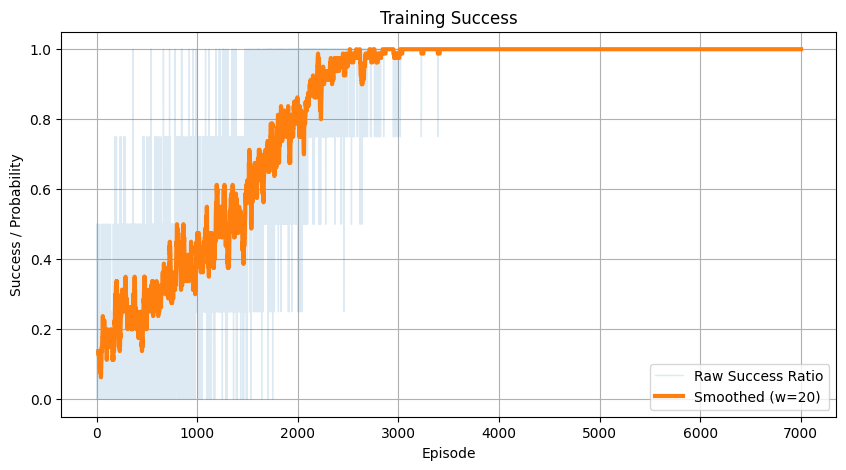

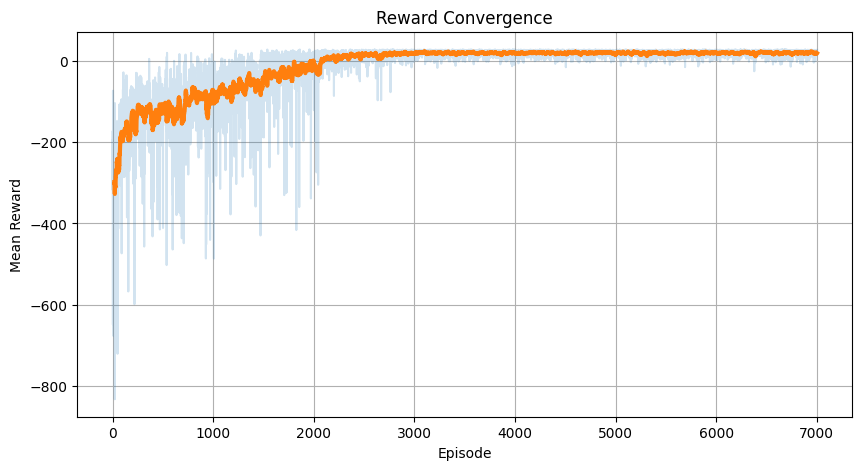

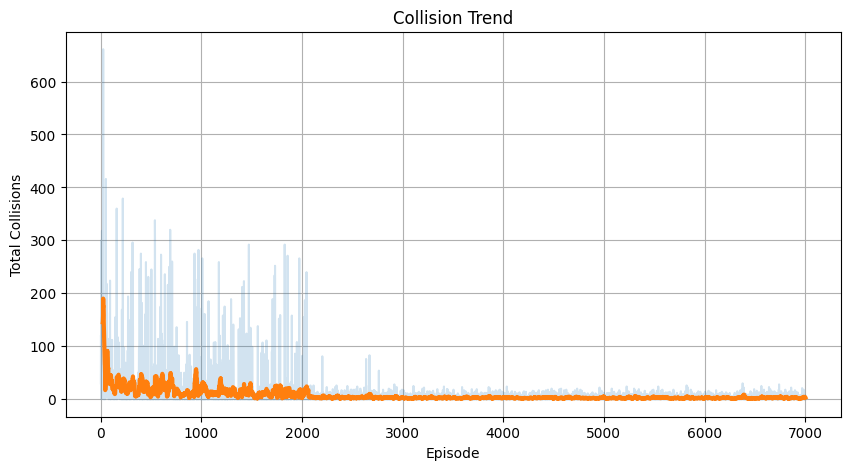

In [4]:
import csv
import numpy as np
import matplotlib.pyplot as plt

def smooth(x, window=20):
    x = np.asarray(x, dtype=np.float32)
    if window <= 1 or len(x) < window:
        return x, np.arange(len(x))
    y = np.convolve(x, np.ones(window)/window, mode="valid")
    idx = np.arange(window-1, len(x))
    return y, idx

def plot_priorityrealloc_training_fixed_steps(csv_path="baseline_train_log.csv", smooth_window=20):
    episodes = []
    success_ratio = []
    timeout_steps = []
    true_steps = []
    mean_reward = []
    collisions = []

    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames or []

        has_finish = all(k in fieldnames for k in ["uav0_finish","uav1_finish","uav2_finish","uav3_finish"])
        has_coll = all(k in fieldnames for k in ["coll_uav_uav","coll_uav_obs","coll_uav_other_task"])

        for row in reader:
            ep = int(row["episode"])
            episodes.append(ep)

            s = float(row["high_priority_success"])
            success_ratio.append(s)

            ep_len = int(float(row["episode_length"]))
            timeout_steps.append(ep_len)

            mean_reward.append(float(row["avg_reward"]))

            if has_coll:
                collisions.append(
                    float(row["coll_uav_uav"]) +
                    float(row["coll_uav_obs"]) +
                    float(row["coll_uav_other_task"])
                )

            # --------- FIXED STEPS ----------
            if has_finish:
                finishes = np.array([
                    int(float(row["uav0_finish"])),
                    int(float(row["uav1_finish"])),
                    int(float(row["uav2_finish"])),
                    int(float(row["uav3_finish"])),
                ], dtype=int)

                # If all 4 UAVs locked at least once, completion step = last lock step
                if np.all(finishes >= 0):
                    comp_step = int(finishes.max())
                    true_steps.append(comp_step)
                else:
                    # Not fully completed -> keep timeout length
                    true_steps.append(ep_len)
            else:
                true_steps.append(ep_len)

    episodes = np.array(episodes)
    success_ratio = np.array(success_ratio, dtype=np.float32)
    timeout_steps = np.array(timeout_steps, dtype=np.float32)
    true_steps = np.array(true_steps, dtype=np.float32)
    mean_reward = np.array(mean_reward, dtype=np.float32)

    # smoothing
    succ_s, idx1 = smooth(success_ratio, smooth_window)
    rew_s,  idx2 = smooth(mean_reward,  smooth_window)
    ttrue_s, idx3 = smooth(true_steps,    smooth_window)

    # ---- FIG 1: SUCCESS
    plt.figure(figsize=(10,5))
    plt.plot(episodes, success_ratio, alpha=0.15, linewidth=1, label="Raw Success Ratio")
    plt.plot(episodes[idx1], succ_s, linewidth=3, label=f"Smoothed (w={smooth_window})")
    plt.ylim(-0.05, 1.05)
    plt.xlabel("Episode"); plt.ylabel("Success / Probability")
    plt.title("Training Success")
    plt.grid(True); plt.legend()
    plt.show()

    # ---- FIG 2: REWARD
    plt.figure(figsize=(10,5))
    plt.plot(episodes, mean_reward, alpha=0.2)
    plt.plot(episodes[idx2], rew_s, linewidth=3)
    plt.xlabel("Episode"); plt.ylabel("Mean Reward")
    plt.title("Reward Convergence")
    plt.grid(True)
    plt.show()

    # # ---- FIG 3: STEPS (this is wrong bc i forgot to end eps when all reach)
    # plt.figure(figsize=(10,5))
    # plt.plot(episodes, timeout_steps, alpha=0.12, label="Logged Episode Length (mostly timeout)")
    # plt.plot(episodes, true_steps, alpha=0.25, label="Reconstructed Completion Steps (from finish_step_per_uav)")
    # plt.plot(episodes[idx3], ttrue_s, linewidth=3, label=f"Smoothed Completion Steps (w={smooth_window})")
    # plt.xlabel("Episode"); plt.ylabel("Steps")
    # plt.title("Episode Steps (fixed using finish times)")
    # plt.grid(True); plt.legend()
    # plt.show()

    # ---- FIG 4: COLLISIONS
    if len(collisions) == len(episodes) and len(collisions) > 0:
        collisions = np.array(collisions, dtype=np.float32)
        coll_s, idx4 = smooth(collisions, smooth_window)
        plt.figure(figsize=(10,5))
        plt.plot(episodes, collisions, alpha=0.2)
        plt.plot(episodes[idx4], coll_s, linewidth=3)
        plt.xlabel("Episode"); plt.ylabel("Total Collisions")
        plt.title("Collision Trend")
        plt.grid(True)
        plt.show()
    else:
        print("[Info] Collision columns not found in this CSV, so Figure 4 was skipped.")

# Run:
plot_priorityrealloc_training_fixed_steps("baseline_train_log.csv", smooth_window=20)


evaluation

In [ ]:
# ============================================================
# CELL 1: FULL EVALUATION (PriorityRealloc + MATD3) — FIXED
# - Loads trained MATD3 checkpoint
# - Greedy actions (no exploration)
# - Reallocation every step if reallocate_every=1
# - EARLY STOP when ALL 4 HIGH tasks in CURRENT window are completed
# - steps logged as (t+1) (env does not provide info["step"])
# ============================================================

import csv
import pickle
import numpy as np
import torch


def evaluate_PriorityRealloc_MATD3(
    ckpt_path,
    episodes=200,
    seed=2026,
    max_steps=100,
    priority_change_every=300,
    reallocate_every=300,              # 1 = every step
    switch_penalty=0.2,
    eval_csv="priority_realloc_eval_log.csv",
    traj_pkl=None,
    device=None,
):
    env = UAVPriorityRealloc3DEnv(
        seed=seed,
        max_steps=max_steps,
        priority_change_every=priority_change_every,
        n_uavs=4,
        n_tasks=4,
        n_high=4
    )

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])

    agent = MATD3(
        n_agents=env.n_uavs,
        state_dim=state_dim,
        action_dim=action_dim,
        max_action=max_action,
        device=device
    )

    # ✅ YOUR load_checkpoint returns 5 values in this notebook
    _epR, _epL, _epS, _epM, extra = load_checkpoint(ckpt_path, agent, device=device)

    for a in agent.actors:
        a.eval()
    for c in agent.critics:
        c.eval()

    with open(eval_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([
            "episode",
            "high_priority_success",
            "completed_high_total",
            "num_windows",
            "steps",
            "avg_reward",
            "sum_reward",
            "uav0_dist","uav1_dist","uav2_dist","uav3_dist",
            "coll_uav_uav","coll_uav_obs","coll_uav_other_task",
            "uav0_finish","uav1_finish","uav2_finish","uav3_finish",
        ])

    traj_data = [] if traj_pkl is not None else None

    print("\n========== STARTING EVALUATION ==========\n")

    for ep in range(episodes):
        obs, info0 = env.reset(seed=seed + ep)

        total_R = np.zeros(env.n_uavs, dtype=np.float32)
        last_info = info0

        # window tracking (Option A)
        high_now = set(env.get_high_priority_tasks())
        window_done = set()
        completed_high_total = 0
        num_windows = 1

        ep_frames = []

        # initial reallocation
        rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
        obs = env._get_obs()

        steps_taken = 0

        for t in range(max_steps):

            # reallocate periodically
            if (t % int(reallocate_every) == 0):
                rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
                obs = env._get_obs()

            # greedy actions
            actions = agent.select_actions(obs, noise_scale=0.0)
            actions = mask_locked_actions(env, actions)
            actions_env = np.stack(actions, axis=0).astype(np.float32)

            next_obs, rewards, dones, info = env.step(actions_env)
            last_info = info
            total_R += rewards
            steps_taken = t + 1

            # count ONLY new completions
            for ev in info.get("completion_events", []):
                tid = int(ev["task"])
                if tid in high_now:
                    window_done.add(tid)

            # ✅ EARLY STOP: finished ALL 4 HIGH tasks in current window
            if len(window_done) == 4:
                if traj_data is not None:
                    ep_frames.append(env.uav_pos.copy())
                obs = next_obs
                break

            # handle priority change (same logic as training)
            if info.get("priority_changed", False):
                has_more_steps = (t < max_steps - 1) and (not np.any(dones))
                if has_more_steps:
                    completed_high_total += len(window_done)
                    window_done.clear()
                    high_now = set(env.get_high_priority_tasks())
                    num_windows += 1

                    rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
                    next_obs = env._get_obs()

            if traj_data is not None:
                ep_frames.append(env.uav_pos.copy())

            obs = next_obs
            if np.any(dones):
                break

        # close last active window
        completed_high_total += len(window_done)
        success = completed_high_total / (4.0 * float(num_windows))

        steps = int(steps_taken)  # ✅ correct
        ep_dist = last_info.get("ep_dist", np.zeros(env.n_uavs, dtype=np.float32))
        coll_uav_uav = int(last_info.get("coll_uav_uav", 0))
        coll_uav_obs = int(last_info.get("coll_uav_obs", 0))
        coll_other = int(last_info.get("coll_uav_other_task", 0))
        finish = last_info.get("finish_step_per_uav", -np.ones(env.n_uavs, dtype=int))

        mean_reward = float(np.mean(total_R))
        sum_reward = float(np.sum(total_R))

        print(
            f"[EVAL] EP={ep:4d} | "
            f"Success={success:.3f} | "
            f"Windows={num_windows} | "
            f"CompletedHigh={completed_high_total} | "
            f"Steps={steps:3d} | "
            f"MeanR={mean_reward:+8.2f} | "
            f"Coll={coll_uav_uav + coll_uav_obs + coll_other}",
            flush=True
        )

        with open(eval_csv, "a", newline="") as f:
            w = csv.writer(f)
            w.writerow([
                ep,
                float(success),
                int(completed_high_total),
                int(num_windows),
                int(steps),
                float(mean_reward),
                float(sum_reward),
                float(ep_dist[0]), float(ep_dist[1]), float(ep_dist[2]), float(ep_dist[3]),
                coll_uav_uav, coll_uav_obs, coll_other,
                int(finish[0]), int(finish[1]), int(finish[2]), int(finish[3]),
            ])

        if traj_data is not None:
            traj_data.append(ep_frames)

    if traj_data is not None:
        with open(traj_pkl, "wb") as f:
            pickle.dump(traj_data, f)
        print(f"\nSaved trajectories -> {traj_pkl}")

    print(f"\nSaved eval CSV -> {eval_csv}")
    print("\n========== EVALUATION COMPLETE ==========\n")

    return eval_csv, traj_pkl


# ============================
# RUN EVAL (set reallocate_every=1 for every-step)
# ============================
eval_csv, traj = evaluate_PriorityRealloc_MATD3(
    ckpt_path="baseline_train.pth",
    episodes=200,
    seed=2026,
    max_steps=100,
    priority_change_every=300,
    reallocate_every=300,  # ✅ every step
    eval_csv="baseline_eval.csv",
    traj_pkl="baseline_eval.pkl",
)


Loaded checkpoint -> baseline_train.pth
   logs: rewards=7004 eps | lengths=7004 eps | metrics=7004 eps

========== STARTING EVALUATION ==========

[EVAL] EP=   0 | Success=1.000 | Windows=1 | CompletedHigh=4 | Steps= 15 | MeanR=  +11.77 | Coll=1
[EVAL] EP=   1 | Success=1.000 | Windows=1 | CompletedHigh=4 | Steps= 13 | MeanR=  +13.83 | Coll=0
[EVAL] EP=   2 | Success=1.000 | Windows=1 | CompletedHigh=4 | Steps= 29 | MeanR=   +6.86 | Coll=1
[EVAL] EP=   3 | Success=1.000 | Windows=1 | CompletedHigh=4 | Steps= 23 | MeanR=   +9.37 | Coll=2
[EVAL] EP=   4 | Success=1.000 | Windows=1 | CompletedHigh=4 | Steps= 15 | MeanR=  +14.06 | Coll=0
[EVAL] EP=   5 | Success=1.000 | Windows=1 | CompletedHigh=4 | Steps= 15 | MeanR=  +12.73 | Coll=0
[EVAL] EP=   6 | Success=1.000 | Windows=1 | CompletedHigh=4 | Steps= 17 | MeanR=  +12.90 | Coll=0
[EVAL] EP=   7 | Success=1.000 | Windows=1 | CompletedHigh=4 | Steps= 17 | MeanR=  +13.27 | Coll=0
[EVAL] EP=   8 | Success=1.000 | Windows=1 | CompletedHigh=4

In [2]:
# ============================
# CELL 2: LOAD SAVED EVAL (NO RERUN) — UPDATED FOR YOUR NEW EVAL OUTPUT
# ============================

import pickle
import numpy as np

def load_saved_eval(pkl_path):
    with open(pkl_path, "rb") as f:
        payload = pickle.load(f)

    # NEW format: traj_pkl is a LIST of episode frames (not a dict)
    if isinstance(payload, list):
        rollouts = payload                      # list[episode] -> list[step] -> uav_pos
        episodes = list(range(len(rollouts)))
        summary = {"episodes": len(episodes), "note": "Loaded rollouts only (metrics are in the eval CSV)."}
        results = [{"episode": ep, "steps": len(rollouts[ep])} for ep in episodes]
        logs = {}
        extra = {}
        print("✅ Loaded saved eval rollouts:", pkl_path)
        print("   episodes:", len(episodes))
        print("   summary:", summary)
        return summary, results, episodes, logs, extra, rollouts

    # OLD format: payload is a dict with summary/results/episodes
    summary = payload["summary"]
    results = payload["results"]
    episodes = payload["episodes"]
    logs = payload.get("train_logs", {})
    extra = payload.get("train_extra", {})
    print("✅ Loaded saved eval:", pkl_path)
    print("   episodes:", len(episodes))
    print("   summary:", summary)
    return summary, results, episodes, logs, extra, payload.get("rollouts", None)


# ---- use the file you actually saved in evaluation ----
summary_loaded, results_loaded, episodes_loaded, logs_loaded, extra_loaded, rollouts_loaded = load_saved_eval(
    "baseline_eval.pkl"
)

print("Example result[0]:", results_loaded[0])
print("Example rollout steps:", len(rollouts_loaded[0]) if rollouts_loaded is not None else None)


✅ Loaded saved eval rollouts: baseline_eval.pkl
   episodes: 200
   summary: {'episodes': 200, 'note': 'Loaded rollouts only (metrics are in the eval CSV).'}
Example result[0]: {'episode': 0, 'steps': 15}
Example rollout steps: 15


In [4]:
# ============================
# LOAD BASELINE METRICS FROM CSV
# ============================

import csv
import numpy as np

def load_baseline_eval_csv(csv_path):
    rows = []
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({
                "episode": int(row["episode"]),
                "high_priority_success": float(row["high_priority_success"]),
                "completed_high_total": int(row["completed_high_total"]),
                "num_windows": int(row["num_windows"]),
                "steps": int(row["steps"]),
                "avg_reward": float(row["avg_reward"]),
                "sum_reward": float(row["sum_reward"]),
                "coll_uav_uav": int(row["coll_uav_uav"]),
                "coll_uav_obs": int(row["coll_uav_obs"]),
                "coll_uav_other_task": int(row["coll_uav_other_task"]),
            })
    return rows

baseline_rows = load_baseline_eval_csv("baseline_eval.csv")

success_vals = np.array([r["high_priority_success"] for r in baseline_rows], dtype=np.float32)
steps_vals = np.array([r["steps"] for r in baseline_rows], dtype=np.float32)
collisions_vals = np.array([
    r["coll_uav_uav"] + r["coll_uav_obs"] + r["coll_uav_other_task"]
    for r in baseline_rows
], dtype=np.float32)

avg_success = float(np.mean(success_vals))
avg_steps = float(np.mean(steps_vals))
avg_collisions = float(np.mean(collisions_vals))

print("\n===== BASELINE EVALUATION (LOADED FROM CSV) =====")
print(f"Episodes: {len(baseline_rows)}")
print(f"Average success: {avg_success:.4f}")
print(f"Average steps: {avg_steps:.2f}")
print(f"Average total collisions per episode: {avg_collisions:.4f}")


===== BASELINE EVALUATION (LOADED FROM CSV) =====
Episodes: 200
Average success: 0.9987
Average steps: 21.20
Average total collisions per episode: 1.1050


# comparison with TANET

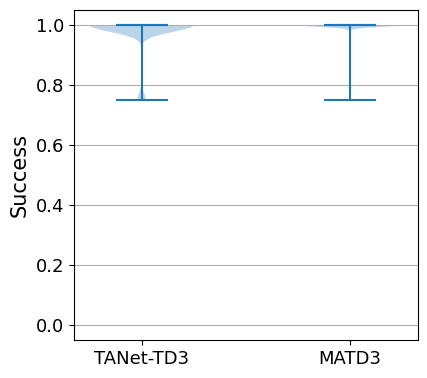

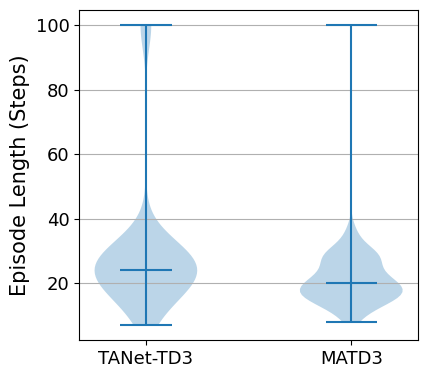

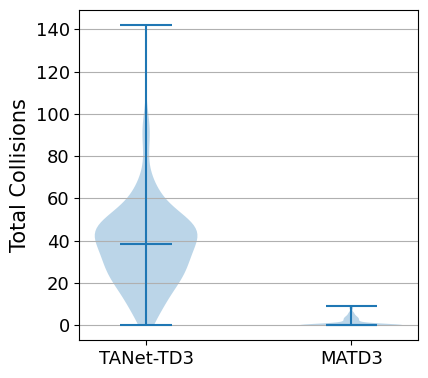

In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

def _read_tanet_eval(csv_path):
    ep, succ, steps, coll = [], [], [], []
    with open(csv_path, "r", newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            ep.append(int(row["episode"]))
            succ.append(float(row["success_ratio"]))
            steps.append(float(row["steps"]))
            coll.append(float(row["collisions"]))
    return np.array(ep), np.array(succ), np.array(steps), np.array(coll)


def _read_matd3_eval(csv_path):
    ep, succ, steps, coll = [], [], [], []
    with open(csv_path, "r", newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            ep.append(int(row["episode"]))
            succ.append(float(row["high_priority_success"]))
            steps.append(float(row["steps"]))
            coll.append(
                float(row.get("coll_uav_uav", 0.0)) +
                float(row.get("coll_uav_obs", 0.0)) +
                float(row.get("coll_uav_other_task", 0.0))
            )
    return np.array(ep), np.array(succ), np.array(steps), np.array(coll)


def _violin_two(ax, data_left, data_right, labels):
    ax.violinplot(
        [data_left, data_right],
        positions=[1, 2],
        showmeans=False,
        showmedians=True,
        showextrema=True
    )
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels)
    ax.grid(True, axis="y")


def _save_violin(data_left, data_right, labels, ylabel, filename, ylim=None):
    fig, ax = plt.subplots(figsize=(4.5,4))

    _violin_two(ax, data_left, data_right, labels)
    ax.set_ylabel(ylabel)

    if ylim is not None:
        ax.set_ylim(*ylim)

    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_violin_figures(
    tanet_eval_csv,
    matd3_eval_csv,
    tanet_label="TANet-TD3",
    matd3_label="MATD3",
):

    _, succ_t, steps_t, coll_t = _read_tanet_eval(tanet_eval_csv)
    _, succ_m, steps_m, coll_m = _read_matd3_eval(matd3_eval_csv)

    n = min(len(succ_t), len(succ_m))
    succ_t, steps_t, coll_t = succ_t[:n], steps_t[:n], coll_t[:n]
    succ_m, steps_m, coll_m = succ_m[:n], steps_m[:n], coll_m[:n]

    labels = [tanet_label, matd3_label]

    # Success
    _save_violin(
        succ_t, succ_m, labels,
        ylabel="Success",
        filename="violin_success.png",
        ylim=(-0.05,1.05)
    )

    # Episode length
    _save_violin(
        steps_t, steps_m, labels,
        ylabel="Episode Length (Steps)",
        filename="violin_episode_length.png"
    )

    # Collisions
    _save_violin(
        coll_t, coll_m, labels,
        ylabel="Total Collisions",
        filename="violin_collisions.png"
    )


# RUN
save_violin_figures(
    tanet_eval_csv="tanet_td3_eval_log.csv",
    matd3_eval_csv="baseline_eval.csv",
)

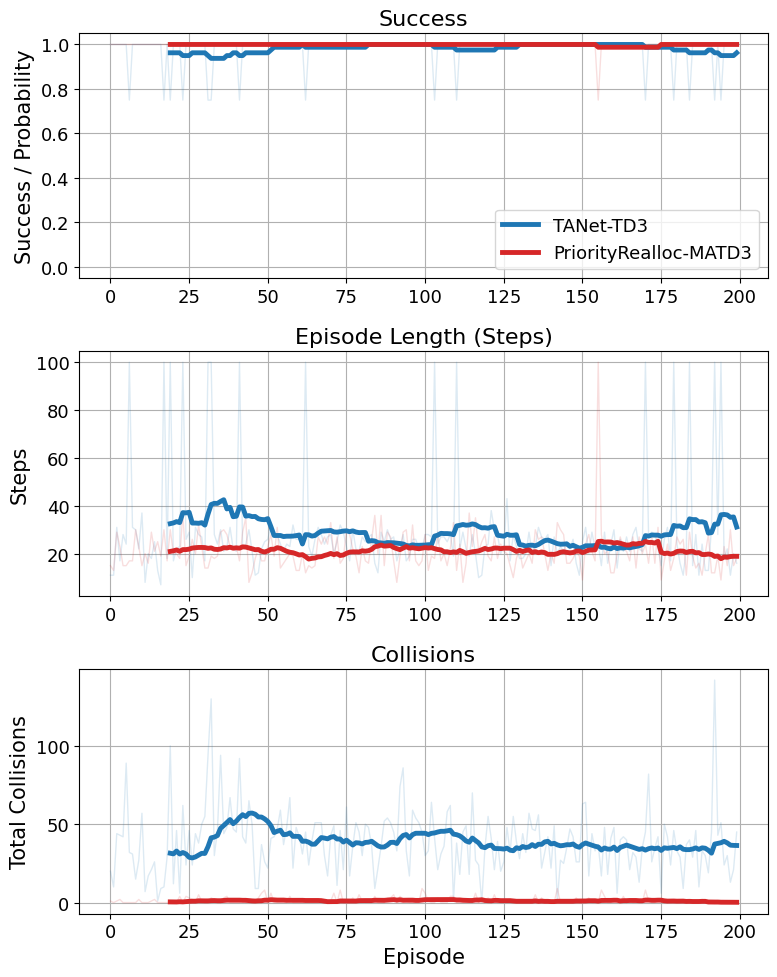

In [18]:
# ============================================================
# CELL 2: PLOT EVAL COMPARISON (TANet vs PriorityRealloc)
# -> ONE FIGURE, 3 SUBPLOTS (Success / Steps / Collisions)
# -> Legend inside first subplot
# -> Only SMOOTHED curves in legend
# -> Larger fonts for paper figures
# ============================================================

import csv
import numpy as np
import matplotlib.pyplot as plt

T_COLOR = "tab:blue"   # TANet
P_COLOR = "tab:red"     # PriorityRealloc

# --------------------------
# FIGURE FONT SETTINGS
# --------------------------
plt.rcParams.update({
    "font.size": 14,          # base text
    "axes.titlesize": 16,     # subplot titles
    "axes.labelsize": 15,     # x/y labels
    "xtick.labelsize": 13,    # tick labels
    "ytick.labelsize": 13,
    "legend.fontsize": 13,    # legend text
    "figure.titlesize": 16,
})


def smooth(x, window=20):
    x = np.asarray(x, dtype=np.float32)
    if window <= 1 or len(x) < window:
        return x, np.arange(len(x))
    y = np.convolve(x, np.ones(window) / window, mode="valid")
    idx = np.arange(window - 1, len(x))
    return y, idx


def _read_tanet_eval(csv_path):
    ep, succ, steps, coll = [], [], [], []
    with open(csv_path, "r", newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            ep.append(int(row["episode"]))
            succ.append(float(row["success_ratio"]))
            steps.append(float(row["steps"]))
            coll.append(float(row["collisions"]))
    return np.array(ep), np.array(succ), np.array(steps), np.array(coll)


def _read_priority_eval(csv_path):
    ep, succ, steps, coll = [], [], [], []
    with open(csv_path, "r", newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            ep.append(int(row["episode"]))
            succ.append(float(row["high_priority_success"]))
            steps.append(float(row["steps"]))
            coll.append(
                float(row.get("coll_uav_uav", 0.0)) +
                float(row.get("coll_uav_obs", 0.0)) +
                float(row.get("coll_uav_other_task", 0.0))
            )
    return np.array(ep), np.array(succ), np.array(steps), np.array(coll)


def plot_eval_comparison_3subplots(
    tanet_eval_csv,
    priority_eval_csv,
    smooth_window=20,
    tanet_label="TANet-TD3",
    pr_label="PriorityRealloc-MATD3",
):

    ep_t, succ_t, steps_t, coll_t = _read_tanet_eval(tanet_eval_csv)
    ep_p, succ_p, steps_p, coll_p = _read_priority_eval(priority_eval_csv)

    n = min(len(ep_t), len(ep_p))
    ep_t, succ_t, steps_t, coll_t = ep_t[:n], succ_t[:n], steps_t[:n], coll_t[:n]
    ep_p, succ_p, steps_p, coll_p = ep_p[:n], succ_p[:n], steps_p[:n], coll_p[:n]

    succ_t_s, idx_t1 = smooth(succ_t, smooth_window)
    succ_p_s, idx_p1 = smooth(succ_p, smooth_window)

    steps_t_s, idx_t2 = smooth(steps_t, smooth_window)
    steps_p_s, idx_p2 = smooth(steps_p, smooth_window)

    coll_t_s, idx_t3 = smooth(coll_t, smooth_window)
    coll_p_s, idx_p3 = smooth(coll_p, smooth_window)

    x_t1, x_p1 = ep_t[idx_t1], ep_p[idx_p1]
    x_t2, x_p2 = ep_t[idx_t2], ep_p[idx_p2]
    x_t3, x_p3 = ep_t[idx_t3], ep_p[idx_p3]

    # Bigger figure size also helps readability in paper
    fig, axes = plt.subplots(3, 1, figsize=(8, 10))
    ax1, ax2, ax3 = axes

    raw_lw = 1.0
    smooth_lw = 3.5

    # =========================
    # SUCCESS
    # =========================
    ax1.plot(ep_t, succ_t, alpha=0.15, linewidth=raw_lw, color=T_COLOR)
    ax1.plot(ep_p, succ_p, alpha=0.15, linewidth=raw_lw, color=P_COLOR)

    ax1.plot(x_t1, succ_t_s, linewidth=smooth_lw, color=T_COLOR, label=tanet_label)
    ax1.plot(x_p1, succ_p_s, linewidth=smooth_lw, color=P_COLOR, label=pr_label)

    ax1.set_ylim(-0.05, 1.05)
    ax1.set_ylabel("Success / Probability")
    ax1.set_title("Success")
    ax1.grid(True)
    ax1.legend(loc="lower right", frameon=True)

    # =========================
    # STEPS
    # =========================
    ax2.plot(ep_t, steps_t, alpha=0.15, linewidth=raw_lw, color=T_COLOR)
    ax2.plot(ep_p, steps_p, alpha=0.15, linewidth=raw_lw, color=P_COLOR)

    ax2.plot(x_t2, steps_t_s, linewidth=smooth_lw, color=T_COLOR)
    ax2.plot(x_p2, steps_p_s, linewidth=smooth_lw, color=P_COLOR)

    ax2.set_ylabel("Steps")
    ax2.set_title("Episode Length (Steps)")
    ax2.grid(True)

    # =========================
    # COLLISIONS
    # =========================
    ax3.plot(ep_t, coll_t, alpha=0.15, linewidth=raw_lw, color=T_COLOR)
    ax3.plot(ep_p, coll_p, alpha=0.15, linewidth=raw_lw, color=P_COLOR)

    ax3.plot(x_t3, coll_t_s, linewidth=smooth_lw, color=T_COLOR)
    ax3.plot(x_p3, coll_p_s, linewidth=smooth_lw, color=P_COLOR)

    ax3.set_xlabel("Episode")
    ax3.set_ylabel("Total Collisions")
    ax3.set_title("Collisions")
    ax3.grid(True)

    fig.tight_layout()
    plt.show()


plot_eval_comparison_3subplots(
    tanet_eval_csv="tanet_td3_eval_log.csv",
    priority_eval_csv="baseline_eval.csv",
    smooth_window=20
)


sweep obs


SWEEP EVALUATION: n_obstacles = 1
Loaded checkpoint -> baseline_train.pth
[EVAL n_obs=1] ep=000 | steps= 16 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=1] ep=001 | steps= 12 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=1] ep=002 | steps= 33 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=1] ep=003 | steps= 13 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=1] ep=004 | steps= 22 | success=1.000 | coll=4 (uav=0, obs=0, other=4)
[EVAL n_obs=1] ep=005 | steps= 29 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=1] ep=006 | steps= 17 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=1] ep=007 | steps= 15 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=1] ep=008 | steps= 16 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=1] ep=009 | steps= 22 | success=1.000 | coll=1 (uav=0, obs=1, other=0)
[EVAL n_obs=1] ep=010 | steps= 17 | success=1.000 | coll=0 (uav=0, obs=0, other=0)
[EVAL n_obs=

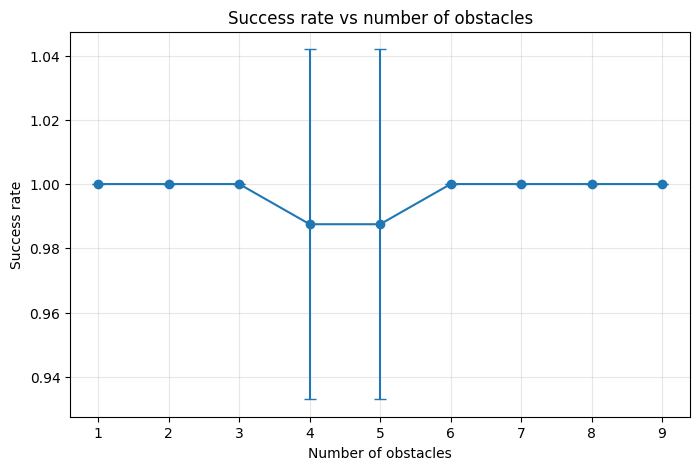

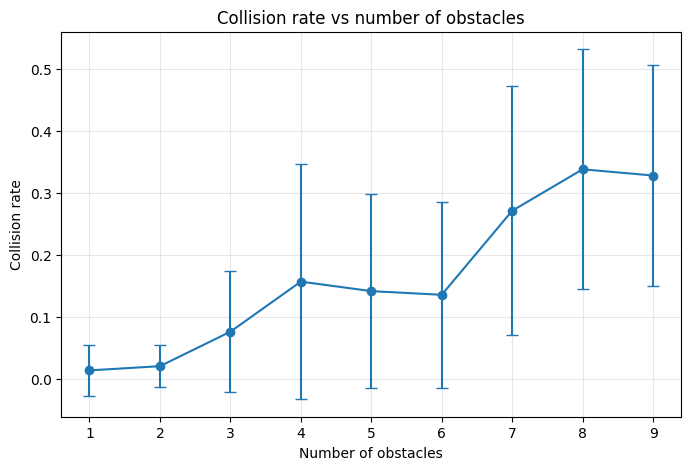

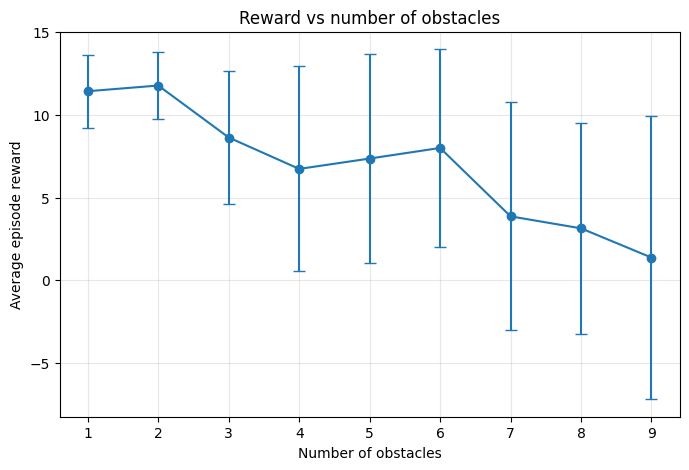

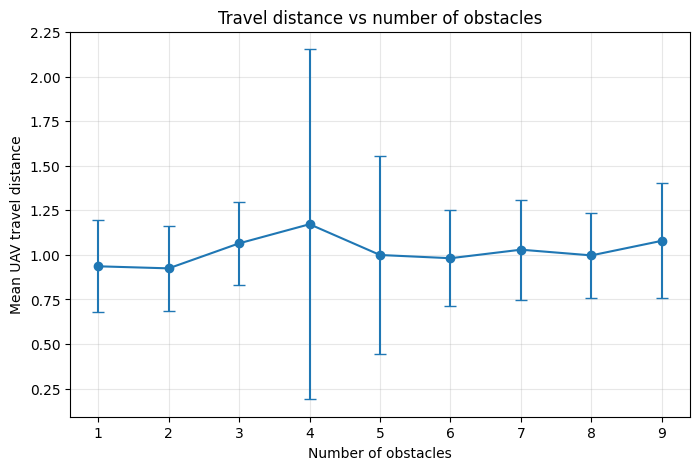

In [6]:
# ============================================================
# SWEEP EVALUATION FOR THE NEW TANET-STYLE METRIC ENV
# - No retraining
# - Uses saved checkpoint as-is
# - Sweeps number of obstacles
# - Saves:
#     1) summary CSV
#     2) per-episode CSV
#     3) PKL payload
# - Uses env's own metrics:
#     ep_dist, coll_uav_uav, coll_uav_obs, coll_uav_other_task, finish_step_per_uav
# ============================================================

import os
import csv
import time
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt


def _assert_defined(name: str):
    if name not in globals():
        raise NameError(f"Missing `{name}`. Run the cell that defines `{name}` first.")


def load_checkpoint_into_agent(path, agent, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(path, map_location=device)

    for i in range(agent.n_agents):
        agent.actors[i].load_state_dict(ckpt["agent"]["actors"][i])
        agent.actor_targets[i].load_state_dict(ckpt["agent"]["actor_targets"][i])
        agent.critics[i].load_state_dict(ckpt["agent"]["critics"][i])
        agent.critic_targets[i].load_state_dict(ckpt["agent"]["critic_targets"][i])

    logs = ckpt.get("logs", {})
    extra = ckpt.get("extra", {})
    print(f"Loaded checkpoint -> {path}")
    return agent, logs, extra


@torch.no_grad()
def evaluate_single_setting(
    ckpt_path,
    n_obstacles,
    n_episodes=20,
    seed0=2025,
    max_steps=300,
    priority_change_every=300,
    reallocate_every=300,
    switch_penalty=0.2,
    n_uavs=4,
    n_tasks=4,
    n_high=4,
    ru=0.02,
    device=None,
):
    """
    Evaluate the already-trained agent for ONE obstacle count.
    Uses env-native metrics:
      - ep_dist
      - coll_uav_uav
      - coll_uav_obs
      - coll_uav_other_task
      - finish_step_per_uav
    """

    _assert_defined("UAVPriorityRealloc3DEnv")
    _assert_defined("MATD3")
    _assert_defined("rl_reallocate_high_priority")
    _assert_defined("mask_locked_actions")

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # temp env for dimensions
    env_tmp = UAVPriorityRealloc3DEnv(
        seed=0,
        max_steps=max_steps,
        priority_change_every=priority_change_every,
        n_uavs=n_uavs,
        n_tasks=n_tasks,
        n_high=n_high,
        n_obstacles=n_obstacles,
        ru=ru,
    )

    agent = MATD3(
        n_agents=env_tmp.n_uavs,
        state_dim=env_tmp.observation_space.shape[0],
        action_dim=env_tmp.action_space.shape[0],
        max_action=float(env_tmp.action_space.high[0]),
        device=device,
    )

    agent, logs, extra = load_checkpoint_into_agent(ckpt_path, agent, device=device)

    results = []
    t0 = time.time()

    for ep in range(int(n_episodes)):
        env = UAVPriorityRealloc3DEnv(
            seed=seed0 + ep,
            max_steps=max_steps,
            priority_change_every=priority_change_every,
            n_uavs=n_uavs,
            n_tasks=n_tasks,
            n_high=n_high,
            n_obstacles=n_obstacles,
            ru=ru,
        )

        obs, _ = env.reset(seed=seed0 + ep)

        # same success logic as training
        high_now = set(env.get_high_priority_tasks())
        window_done = set()
        completed_high_total = 0
        num_windows = 1

        rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
        obs = env._get_obs()

        total_r = np.zeros(env.n_uavs, dtype=np.float32)
        last_info = {}
        steps_run = 0

        for t in range(int(max_steps)):
            if (t % int(reallocate_every) == 0):
                rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
                obs = env._get_obs()

            actions = agent.select_actions(obs, noise_scale=0.0)
            actions = mask_locked_actions(env, actions)
            actions_env = np.stack(actions, axis=0).astype(np.float32)

            next_obs, rewards, dones, info = env.step(actions_env)
            last_info = info
            total_r += rewards
            steps_run = int(t + 1)

            # count new completions in current window
            for ev in info.get("completion_events", []):
                tid = int(ev["task"])
                if tid in high_now:
                    window_done.add(tid)

            # handle priority change
            if info.get("priority_changed", False):
                is_final_env_step = bool(
                    getattr(env, "step_count", 0) >= int(getattr(env, "max_steps", max_steps))
                )
                has_more_steps = (not is_final_env_step) and (not np.any(dones))

                if has_more_steps:
                    completed_high_total += len(window_done)
                    window_done.clear()
                    high_now = set(env.get_high_priority_tasks())
                    num_windows += 1

                    rl_reallocate_high_priority(agent, env, switch_penalty=switch_penalty)
                    next_obs = env._get_obs()

            obs = next_obs

            if np.any(dones):
                break

        completed_high_total += len(window_done)

        success = completed_high_total / (float(n_high) * float(num_windows))

        ep_dist = np.array(last_info.get("ep_dist", np.zeros(env.n_uavs)), dtype=np.float32)
        finish = np.array(last_info.get("finish_step_per_uav", -np.ones(env.n_uavs)), dtype=np.int32)

        coll_uav_uav = int(last_info.get("coll_uav_uav", 0))
        coll_uav_obs = int(last_info.get("coll_uav_obs", 0))
        coll_uav_other_task = int(last_info.get("coll_uav_other_task", 0))
        total_collisions = int(coll_uav_uav + coll_uav_obs + coll_uav_other_task)
        collision_rate = float(total_collisions / max(steps_run, 1))

        valid_finish = finish[finish >= 0]
        mean_finish_step = float(np.mean(valid_finish)) if len(valid_finish) > 0 else np.nan

        res = {
            "episode": int(ep),
            "seed": int(seed0 + ep),
            "n_obstacles": int(n_obstacles),
            "steps": int(steps_run),
            "windows": int(num_windows),
            "completed_high_total": int(completed_high_total),
            "success": float(success),
            "avg_reward_episode": float(np.mean(total_r)),

            "uav0_dist": float(ep_dist[0]) if len(ep_dist) > 0 else np.nan,
            "uav1_dist": float(ep_dist[1]) if len(ep_dist) > 1 else np.nan,
            "uav2_dist": float(ep_dist[2]) if len(ep_dist) > 2 else np.nan,
            "uav3_dist": float(ep_dist[3]) if len(ep_dist) > 3 else np.nan,
            "mean_uav_dist": float(np.mean(ep_dist)) if len(ep_dist) > 0 else np.nan,

            "coll_uav_uav": coll_uav_uav,
            "coll_uav_obs": coll_uav_obs,
            "coll_uav_other_task": coll_uav_other_task,
            "total_collisions": total_collisions,
            "collision_rate": collision_rate,

            "uav0_finish": int(finish[0]) if len(finish) > 0 else -1,
            "uav1_finish": int(finish[1]) if len(finish) > 1 else -1,
            "uav2_finish": int(finish[2]) if len(finish) > 2 else -1,
            "uav3_finish": int(finish[3]) if len(finish) > 3 else -1,
            "mean_finish_step": float(mean_finish_step) if not np.isnan(mean_finish_step) else np.nan,
        }
        results.append(res)

        print(
            f"[EVAL n_obs={n_obstacles}] ep={ep:03d} | steps={res['steps']:3d} "
            f"| success={res['success']:.3f} | coll={res['total_collisions']} "
            f"(uav={res['coll_uav_uav']}, obs={res['coll_uav_obs']}, other={res['coll_uav_other_task']})"
        )

    succ = np.array([r["success"] for r in results], dtype=np.float32)
    rew = np.array([r["avg_reward_episode"] for r in results], dtype=np.float32)
    col = np.array([r["collision_rate"] for r in results], dtype=np.float32)
    stp = np.array([r["steps"] for r in results], dtype=np.float32)
    dst = np.array([r["mean_uav_dist"] for r in results], dtype=np.float32)

    summary = {
        "ckpt": str(ckpt_path),
        "n_obstacles": int(n_obstacles),
        "n_episodes": int(n_episodes),

        "success_mean": float(np.mean(succ)),
        "success_std": float(np.std(succ)),

        "avg_reward_mean": float(np.mean(rew)),
        "avg_reward_std": float(np.std(rew)),

        "collision_rate_mean": float(np.mean(col)),
        "collision_rate_std": float(np.std(col)),

        "steps_mean": float(np.mean(stp)),
        "steps_std": float(np.std(stp)),

        "mean_uav_dist_mean": float(np.mean(dst)),
        "mean_uav_dist_std": float(np.std(dst)),

        "elapsed_sec": float(time.time() - t0),
    }

    return results, summary, logs, extra


@torch.no_grad()
def sweep_obstacles_evaluate(
    ckpt_path,
    obstacle_list=(1, 2, 3, 4, 5, 6,7,8,9),
    out_prefix="baseline_from_center_updated1_obstacle_sweep",
    n_episodes=20,
    seed0=2025,
    max_steps=300,
    priority_change_every=300,
    reallocate_every=300,
    switch_penalty=0.2,
    n_uavs=4,
    n_tasks=4,
    n_high=4,
    ru=0.02,
    device=None,
    make_plot=True,
):
    all_summary_rows = []
    all_episode_rows = []

    payload = {
        "ckpt_path": ckpt_path,
        "settings": {
            "obstacle_list": list(obstacle_list),
            "n_episodes": int(n_episodes),
            "seed0": int(seed0),
            "max_steps": int(max_steps),
            "priority_change_every": int(priority_change_every),
            "reallocate_every": int(reallocate_every),
            "switch_penalty": float(switch_penalty),
            "n_uavs": int(n_uavs),
            "n_tasks": int(n_tasks),
            "n_high": int(n_high),
            "ru": float(ru),
        },
        "per_setting": {}
    }

    for n_obs in obstacle_list:
        print("\n" + "=" * 80)
        print(f"SWEEP EVALUATION: n_obstacles = {n_obs}")
        print("=" * 80)

        results, summary, logs, extra = evaluate_single_setting(
            ckpt_path=ckpt_path,
            n_obstacles=int(n_obs),
            n_episodes=n_episodes,
            seed0=seed0,
            max_steps=max_steps,
            priority_change_every=priority_change_every,
            reallocate_every=reallocate_every,
            switch_penalty=switch_penalty,
            n_uavs=n_uavs,
            n_tasks=n_tasks,
            n_high=n_high,
            ru=ru,
            device=device,
        )

        all_summary_rows.append(summary)
        all_episode_rows.extend(results)

        payload["per_setting"][int(n_obs)] = {
            "summary": summary,
            "results": results,
            "train_logs": logs,
            "train_extra": extra,
        }

    summary_csv = f"{out_prefix}_summary.csv"
    episodes_csv = f"{out_prefix}_episodes.csv"
    pkl_path = f"{out_prefix}.pkl"

    # -------------------------
    # save summary csv
    # -------------------------
    with open(summary_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "n_obstacles",
            "n_episodes",
            "success_mean",
            "success_std",
            "avg_reward_mean",
            "avg_reward_std",
            "collision_rate_mean",
            "collision_rate_std",
            "steps_mean",
            "steps_std",
            "mean_uav_dist_mean",
            "mean_uav_dist_std",
            "elapsed_sec",
            "ckpt",
        ])
        for row in all_summary_rows:
            writer.writerow([
                row["n_obstacles"],
                row["n_episodes"],
                row["success_mean"],
                row["success_std"],
                row["avg_reward_mean"],
                row["avg_reward_std"],
                row["collision_rate_mean"],
                row["collision_rate_std"],
                row["steps_mean"],
                row["steps_std"],
                row["mean_uav_dist_mean"],
                row["mean_uav_dist_std"],
                row["elapsed_sec"],
                row["ckpt"],
            ])

    # -------------------------
    # save per-episode csv
    # -------------------------
    with open(episodes_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "episode",
            "seed",
            "n_obstacles",
            "steps",
            "windows",
            "completed_high_total",
            "success",
            "avg_reward_episode",

            "uav0_dist",
            "uav1_dist",
            "uav2_dist",
            "uav3_dist",
            "mean_uav_dist",

            "coll_uav_uav",
            "coll_uav_obs",
            "coll_uav_other_task",
            "total_collisions",
            "collision_rate",

            "uav0_finish",
            "uav1_finish",
            "uav2_finish",
            "uav3_finish",
            "mean_finish_step",
        ])
        for row in all_episode_rows:
            writer.writerow([
                row["episode"],
                row["seed"],
                row["n_obstacles"],
                row["steps"],
                row["windows"],
                row["completed_high_total"],
                row["success"],
                row["avg_reward_episode"],

                row["uav0_dist"],
                row["uav1_dist"],
                row["uav2_dist"],
                row["uav3_dist"],
                row["mean_uav_dist"],

                row["coll_uav_uav"],
                row["coll_uav_obs"],
                row["coll_uav_other_task"],
                row["total_collisions"],
                row["collision_rate"],

                row["uav0_finish"],
                row["uav1_finish"],
                row["uav2_finish"],
                row["uav3_finish"],
                row["mean_finish_step"],
            ])

    with open(pkl_path, "wb") as f:
        pickle.dump(payload, f)

    print("\nSAVED:")
    print("  Summary CSV :", summary_csv)
    print("  Episodes CSV:", episodes_csv)
    print("  PKL         :", pkl_path)

    if make_plot:
        x = [row["n_obstacles"] for row in all_summary_rows]

        y_s = [row["success_mean"] for row in all_summary_rows]
        e_s = [row["success_std"] for row in all_summary_rows]

        y_c = [row["collision_rate_mean"] for row in all_summary_rows]
        e_c = [row["collision_rate_std"] for row in all_summary_rows]

        y_r = [row["avg_reward_mean"] for row in all_summary_rows]
        e_r = [row["avg_reward_std"] for row in all_summary_rows]

        y_d = [row["mean_uav_dist_mean"] for row in all_summary_rows]
        e_d = [row["mean_uav_dist_std"] for row in all_summary_rows]

        plt.figure(figsize=(8, 5))
        plt.errorbar(x, y_s, yerr=e_s, marker="o", capsize=4)
        plt.xlabel("Number of obstacles")
        plt.ylabel("Success rate")
        plt.title("Success rate vs number of obstacles")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.errorbar(x, y_c, yerr=e_c, marker="o", capsize=4)
        plt.xlabel("Number of obstacles")
        plt.ylabel("Collision rate")
        plt.title("Collision rate vs number of obstacles")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.errorbar(x, y_r, yerr=e_r, marker="o", capsize=4)
        plt.xlabel("Number of obstacles")
        plt.ylabel("Average episode reward")
        plt.title("Reward vs number of obstacles")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.errorbar(x, y_d, yerr=e_d, marker="o", capsize=4)
        plt.xlabel("Number of obstacles")
        plt.ylabel("Mean UAV travel distance")
        plt.title("Travel distance vs number of obstacles")
        plt.grid(True, alpha=0.3)
        plt.show()

    return all_summary_rows, all_episode_rows, summary_csv, episodes_csv, pkl_path


# ----------------------------
# RUN EXAMPLE
# ----------------------------
sweep_summary, sweep_episodes, summary_csv, episodes_csv, sweep_pkl = sweep_obstacles_evaluate(
    ckpt_path="baseline_train.pth",
    obstacle_list=[1, 2, 3, 4, 5, 6, 7, 8,9],
    out_prefix="baseline_obstacle_sweep",
    n_episodes=20,
    seed0=2023,
    max_steps=300,
    priority_change_every=300,
    reallocate_every=300,
    switch_penalty=0.2,
    n_uavs=4,
    n_tasks=4,
    n_high=4,
    ru=0.02,
    device=None,
    make_plot=True,
)